In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as constants
import referenceFrames as rf

In [2]:
sim = Simulation("MechanicalVignetting")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Enable mechanical vignetting

sim["CCD/IncludeMechanicalVignetting"] = "yes"

In [3]:
pixelSize = sim["CCD/PixelSize"] / 1000.0    # Pixel size [mm]

In [4]:
output = sim.run(removeOutputFile = True)


2020-05-26 13:51:50 WARNING Simulation: no information about detected stars to write to HDF5
2020-05-26 13:51:50 WARNING Camera: No star positions to write to HDF5 file.



In [5]:
image = output.getImage(0)
normalizationFactor = image[0][0]

In [6]:
# Calculate the size of the FOV in pixels
fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(fovDegrees), sim["Camera/FocalLength/ConstantValue"] * 1000, 0)     # Edge of the FOV along the x-axis
radiusPixels, zero = rf.focalPlaneToPixelCoordinates(xFP, yFP, sim["CCD/PixelSize"], 0, 0, 0)     # (size of the FOV, 0)
intersection = math.sqrt(radiusPixels**2 - sim["CCD/NumColumns"]**2)     # Where does the edge of the FOV intersect with the x-axis and the y-axis?

[Text(0, 0, ''),
 Text(0, 0, ''),
 Text(0, 0, '1000'),
 Text(0, 0, '2000'),
 Text(0, 0, '3000'),
 Text(0, 0, '4000'),
 Text(0, 0, ''),
 Text(0, 0, 'y$_{FOV}^*$'),
 Text(0, 0, 'R$_{FOV}$')]

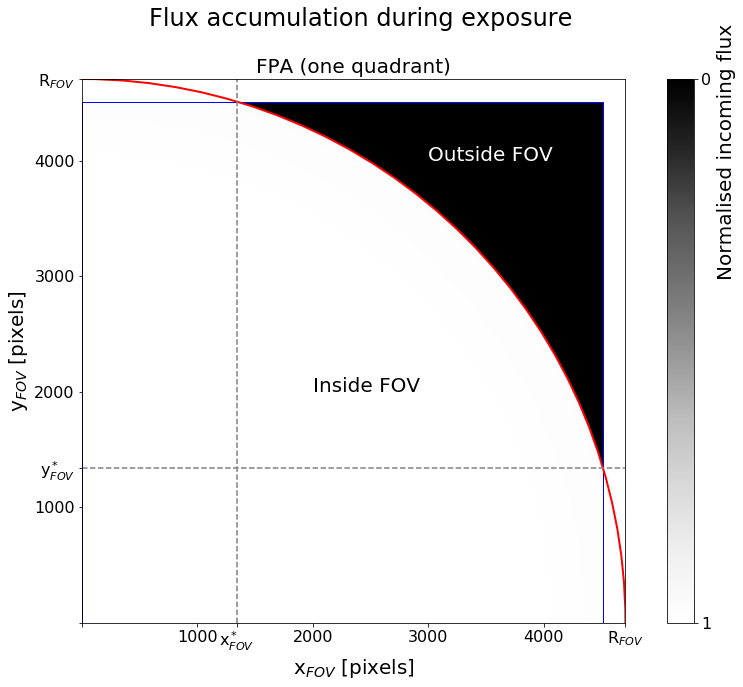

In [7]:
#intersection = np.where(imageNoOffsetWithoutOSS == 0)[0][0]
#intersection = 1339.5569086073087
#radiusPixels = math.sqrt(sim["CCD/NumRows"]**2 + intersection**2)

fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



##########
# Detector
##########

rect = plt.Rectangle((0,0), sim["CCD/NumColumns"], sim["CCD/NumRows"])
ax.add_patch(rect)
rect.set_edgecolor("b")
rect.set_facecolor("none")



#####
# FOV
#####

circ = plt.Circle((0,0), radius = radiusPixels, color = "white", linewidth = 2)
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")



##########################
# Normalised incoming flux
##########################

im = plt.imshow(-image / normalizationFactor, origin='lower', cmap='Greys')



########
# Layout
########

plt.text(2000, 2000, "Inside FOV", fontsize = 20)
plt.text(3000, 4000, "Outside FOV", fontsize = 20, color = "w")

plt.suptitle("Flux accumulation during exposure", fontsize = 24)
plt.title("FPA (one quadrant)", fontsize = 20)
plt.xlabel("x$_{FOV}$ [pixels]", fontsize = 20)
plt.ylabel("y$_{FOV}$ [pixels]", fontsize = 20)

cbar = fig.colorbar(im, ticks=[-1, 0])
cbar.ax.set_yticklabels(['1', '0'], fontsize = 16)  # vertically oriented colorbar

plt.text(5500, 3000, "Normalised incoming flux", fontsize = 20, rotation = 90)

plt.axvline(x = intersection, linestyle = "--", color =  "gray")
plt.axhline(y = intersection, linestyle = "--", color =  "gray")

plt.xticks(list(plt.xticks()[0]) + [intersection, radiusPixels])
plt.yticks(list(plt.yticks()[0]) + [intersection, radiusPixels])
plt.xlim([0, radiusPixels])
plt.ylim([0, radiusPixels])

labels = [item.get_text() for item in ax.get_xticklabels()]
labels[2] = '1000'
labels[3] = '2000'
labels[4] = '3000'
labels[5] = '4000'
labels[7] = 'x$_{FOV}^*$'
labels[8] = 'R$_{FOV}$'
ax.set_xticklabels(labels, fontsize = 16)

labels[7] = 'y$_{FOV}^*$'
ax.set_yticklabels(labels, fontsize = 16)

In [8]:
print(radiusPixels)

4705.590934987844


(-0.001, 0.03)

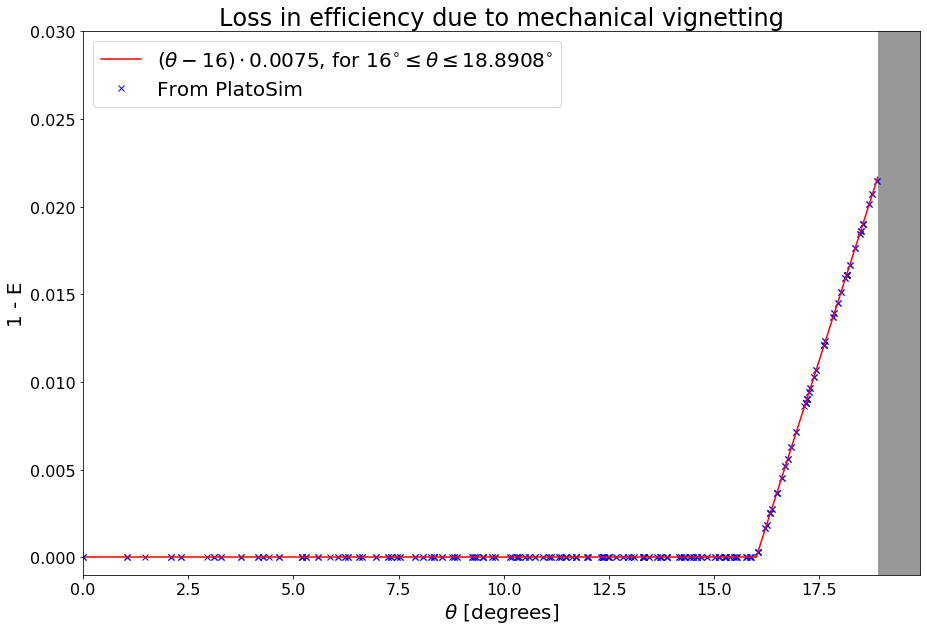

In [9]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

for row in range(0, sim["SubField/NumRows"], 250):
    
    for column in range(0, sim["SubField/NumColumns"], 250):
        
        # Calculate the angular distance of pixel (row, column) from the optical axis
        
        xFP, yFP = rf.pixelToFocalPlaneCoordinates(column, row, sim["CCD/PixelSize"], 0, 0, 0)     # Focal-plane coordinates[mm]
        distance = np.rad2deg(rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, sim["Camera/FocalLength/ConstantValue"] * 1000))     # Angular distance from the OA [degrees]
        
        plt.plot([distance], 1 - image[row, column] / image[0,0], "bx")

        

########
# Theory
########

distances = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 18.89])
mech_vig = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1.280623049, 2.386615683])
slope = 0.5 * (mech_vig[-1] + mech_vig[-2]) / ( 0.5 * (distances[-1] + distances[-2]) - distances[-3]) / 100.
d = np.arange(16, 21)
plt.plot([0, 16], [0, 0], "r-")
label = "$(\\theta - 16) \cdot 0.0075$, for $16^{\circ} \leq \\theta \leq 18.8908^{\circ}$"
plt.plot(distances[-3:], (distances[-3:] - 16) * slope, "r-", label=label)

plt.axvspan(fovDegrees, 20, facecolor='0.2', alpha=0.5)



########
# Layout
########

plt.title("Loss in efficiency due to mechanical vignetting", fontsize = 24)
plt.xlabel("$\\theta$ [degrees]", fontsize = 20)
plt.ylabel("1 - E", fontsize = 20)

plt.plot([0], [0], "bx", label = "From PlatoSim")
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

plt.xlim([-0, fovDegrees + 1])
plt.ylim([-0.001, 0.03])